# Pre-L2 Alpha meta-cluster network and mutation signatures

This notebook builds an exploratory network of Alpha cluster continuity before the second lockdown (L2), then asks whether connected components of that network can be distinguished by amino-acid mutations. It is descriptive: shared mutations and shared rolling-window cluster membership are useful signals, but they are not proof of a single transmission chain or a specific event.

Workflow:

1. Select good-QC, primary-resolution Alpha sequences collected before L2.
2. Create one node for each Alpha-containing cluster/window.
3. Link nodes in adjacent windows when they share at least one sequence.
4. Use connected components as Alpha meta-clusters.
5. Test amino-acid substitutions for enrichment in each meta-cluster against the other pre-L2 Alpha sequences.
6. Track selected signature mutations through time to see which pre-L2 Alpha meta-clusters appear to contribute most to later Alpha burden.


In [1]:
from collections import defaultdict
from pathlib import Path
import re
import warnings

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore", category=FutureWarning)

from utils import style
from utils import data as ld


style.set_theme(font_scale=0.9)

## Parameters

The network is built from sequences collected before L2 and, by default, cluster assignments from windows with midpoint before L2. If you want to include bridge windows that straddle L2, set `NETWORK_WINDOW_CUTOFF` later than `L2_START`.

In [2]:
L2_START = pd.Timestamp("2021-01-05")
NETWORK_WINDOW_CUTOFF = L2_START
TRAJECTORY_END = pd.Timestamp("2021-06-30")

MIN_META_CLUSTER_SEQUENCES = 10
MIN_MUTATION_SEQUENCES = 5
MAX_GLOBAL_MUTATION_PREVALENCE = 0.95
SIGNATURE_MIN_PREVALENCE = 0.55
SIGNATURE_MAX_BACKGROUND = 0.35
SIGNATURE_Q_VALUE = 0.10
SIGNATURES_PER_META_CLUSTER = 3
MAX_TRAJECTORY_MUTATIONS = 10

NEXTCLADE_TSV = Path("../../data/raw/cog-uk/cog_all_scotland_nextclade.tsv")

OUTPUT_TABLE_DIR = Path("tables")
OUTPUT_FIGURE_DIR = Path("figures")
OUTPUT_TABLE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
def mutation_to_col(mutation: str) -> str:
    return re.sub(r"[^0-9A-Za-z]+", "_", mutation).strip("_").lower()


def read_nextclade_aa(sequence_ids: set[str], chunksize: int = 200_000) -> pd.DataFrame:
    """Read raw amino-acid substitution strings for selected sequence IDs."""
    chunks = []
    for chunk in pd.read_csv(
        NEXTCLADE_TSV,
        sep="\t",
        usecols=["seqName", "aaSubstitutions"],
        dtype=str,
        chunksize=chunksize,
        low_memory=False,
    ):
        chunk = chunk[chunk["seqName"].isin(sequence_ids)].copy()
        if chunk.empty:
            continue
        chunk = chunk.rename(columns={"seqName": "sequence_id"})
        chunks.append(chunk)

    if not chunks:
        raise RuntimeError("No requested sequence IDs matched the Nextclade TSV.")

    return pd.concat(chunks, ignore_index=True).drop_duplicates("sequence_id")


def read_nextclade_flags(sequence_ids: set[str], mutations: list[str], chunksize: int = 200_000) -> pd.DataFrame:
    """Read boolean flags for selected amino-acid substitutions."""
    mutations = list(dict.fromkeys(mutations))
    chunks = []
    for chunk in pd.read_csv(
        NEXTCLADE_TSV,
        sep="\t",
        usecols=["seqName", "aaSubstitutions"],
        dtype=str,
        chunksize=chunksize,
        low_memory=False,
    ):
        chunk = chunk[chunk["seqName"].isin(sequence_ids)].copy()
        if chunk.empty:
            continue

        aa = chunk["aaSubstitutions"].fillna("")
        out = pd.DataFrame({"sequence_id": chunk["seqName"].to_numpy()})
        for mutation in mutations:
            out[mutation_to_col(mutation)] = aa.str.contains(mutation, regex=False).astype("int8").to_numpy()
        chunks.append(out)

    if not chunks:
        raise RuntimeError("No requested sequence IDs matched the Nextclade TSV.")

    flags = pd.concat(chunks, ignore_index=True).drop_duplicates("sequence_id")
    return flags


def explode_aa_substitutions(aa: pd.DataFrame) -> pd.DataFrame:
    records = []
    for sequence_id, substitutions in aa[["sequence_id", "aaSubstitutions"]].itertuples(index=False):
        if pd.isna(substitutions):
            continue
        for mutation in str(substitutions).split(","):
            mutation = mutation.strip()
            if mutation and ":" in mutation:
                records.append((sequence_id, mutation))
    return pd.DataFrame(records, columns=["sequence_id", "mutation"])


def join_top(values: pd.Series, n: int = 5) -> str:
    counts = values.dropna().astype(str).value_counts()
    return "; ".join(f"{name} ({count})" for name, count in counts.head(n).items())


def week_start(dates: pd.Series) -> pd.Series:
    dates = pd.to_datetime(dates)
    return dates - pd.to_timedelta(dates.dt.weekday, unit="D")


## Load primary-resolution Alpha rows before L2

In [32]:
columns = [
    "sequence_id", "window_id", "window_idx", "wn_start_date", "wn_mid_date", "wn_end_date",
    "collection_date", "cluster_id", "cluster_size", "cluster_n_datazones",
    "nextclade_qc", "pango_lineage", "who_voc", "dz_health_board", "dz_local_authority",
    "datazone", "age_band", "sex", "dz_simd_quintile",
]

primary = ld.load_analysis_columns_pandas(columns, add_wave=True, add_policy=True)

primary["is_alpha_pango"] = primary["pango_lineage"].str.startswith("B.1.1.7")

# One row per sequence for calendar trajectories and metadata summaries.
primary_sequence = (
    primary.sort_values(["sequence_id", "window_idx"])
    .drop_duplicates("sequence_id")
    .copy()
)

pre_l2_alpha_ids = set(
    primary_sequence.loc[
        primary_sequence["is_alpha_pango"] & (primary_sequence["collection_date"] < L2_START),
        "sequence_id",
    ]
)

network_rows = primary[
    primary["sequence_id"].isin(pre_l2_alpha_ids)
    & (primary["wn_mid_date"] < NETWORK_WINDOW_CUTOFF)
].copy()
network_rows["node_id"] = network_rows["window_id"].astype(str) + "::" + network_rows["cluster_id"].astype(str)

print(f"Primary good-QC sequence rows: {len(primary):,}")
print(f"Unique primary good-QC sequences: {primary_sequence['sequence_id'].nunique():,}")
print(f"Pre-L2 Alpha sequences by collection date: {len(pre_l2_alpha_ids):,}")
print(f"Number of clusters: {network_rows['cluster_id'].nunique():,}")
print(f"Rows available for network construction: {len(network_rows):,}")
print(f"Network windows: {network_rows['window_id'].nunique():,}")

print(network_rows.groupby(["window_id", "window_idx"], as_index=False)["sequence_id"].count())

Primary good-QC sequence rows: 789,347
Unique primary good-QC sequences: 281,320
Pre-L2 Alpha sequences by collection date: 442
Number of clusters: 213
Rows available for network construction: 973
Network windows: 13
   window_id  window_idx  sequence_id
0       W005           5            5
1       W006           6            5
2       W007           7            5
3       W016          16            1
4       W017          17            5
5       W018          18           10
6       W019          19           16
7       W020          20           23
8       W021          21           41
9       W022          22          135
10      W023          23          185
11      W024          24          257
12      W025          25          285


## Build adjacent-window cluster graph

In [34]:
node_table = (
    network_rows.groupby(["node_id", "window_id", "window_idx", "wn_mid_date", "cluster_id"], as_index=False)
    .agg(
        n_alpha_sequences=("sequence_id", "nunique"),
        max_cluster_size=("cluster_size", "max"),
        max_cluster_n_datazones=("cluster_n_datazones", "max"),
        first_collection_date=("collection_date", "min"),
        last_collection_date=("collection_date", "max"),
        health_boards=("dz_health_board", join_top),
        local_authorities=("dz_local_authority", join_top),
    )
    .sort_values(["window_idx", "n_alpha_sequences"], ascending=[True, False])
)

seq_nodes = network_rows[["sequence_id", "node_id", "window_id", "window_idx"]]

edge_map: dict[tuple[str, str], set[str]] = defaultdict(set)
for sequence_id, group in seq_nodes.sort_values("window_idx").groupby("sequence_id"):
    records = list(group[["node_id", "window_idx"]].itertuples(index=False, name=None))
    for i, (node_i, idx_i) in enumerate(records):
        for node_j, idx_j in records[i + 1 :]:
            delta = idx_j - idx_i
            if delta == 1 and node_i != node_j:
                edge_map[tuple(sorted((node_i, node_j)))].add(sequence_id)
            elif delta > 1:
                break

edge_table = pd.DataFrame(
    [
        {
            "source": source,
            "target": target,
            "n_shared_sequences": len(shared),
            "shared_sequences": ";".join(sorted(shared)),
        }
        for (source, target), shared in edge_map.items()
    ]
).sort_values(["n_shared_sequences", "source", "target"], ascending=[False, True, True])

G = nx.Graph()
for row in node_table.itertuples(index=False):
    G.add_node(row.node_id)
for row in edge_table.itertuples(index=False):
    G.add_edge(row.source, row.target, weight=row.n_shared_sequences)

components = sorted(nx.connected_components(G), key=lambda nodes: (-len(nodes), sorted(nodes)[0]))
component_map = {
    node: f"AM{component_idx:03d}"
    for component_idx, nodes in enumerate(components, start=1)
    for node in nodes
}
node_table["meta_cluster_id"] = node_table["node_id"].map(component_map)

print(f"Graph nodes: {G.number_of_nodes():,}")
print(f"Graph edges: {G.number_of_edges():,}")
print(f"Connected components / meta-clusters: {len(components):,}")
display(node_table.head())

Graph nodes: 213
Graph edges: 138
Connected components / meta-clusters: 78


,node_id,window_id,window_idx,wn_mid_date,cluster_id,n_alpha_sequences,max_cluster_size,max_cluster_n_datazones,first_collection_date,last_collection_date,health_boards,local_authorities,meta_cluster_id
0,W005::W005|B.1.1.70|R0.3|C1,W005,5,2020-08-11 12:00:00,W005|B.1.1.70|R0.3|C1,3,3,3,2020-08-17,2020-08-20,Highland (2); Ayrshire and Arran (1),Argyll and Bute (2); South Ayrshire (1),AM009
1,W005::W005|B.1.1.70|R0.3|C2,W005,5,2020-08-11 12:00:00,W005|B.1.1.70|R0.3|C2,2,2,2,2020-08-17,2020-08-17,Lanarkshire (1); Greater Glasgow and Clyde (1),South Lanarkshire (1); Glasgow City (1),AM010
2,W006::W006|B.1.1.70|R0.3|C1,W006,6,2020-08-18 12:00:00,W006|B.1.1.70|R0.3|C1,3,3,3,2020-08-17,2020-08-20,Highland (2); Ayrshire and Arran (1),Argyll and Bute (2); South Ayrshire (1),AM009
3,W006::W006|B.1.1.70|R0.3|C2,W006,6,2020-08-18 12:00:00,W006|B.1.1.70|R0.3|C2,2,2,2,2020-08-17,2020-08-17,Lanarkshire (1); Greater Glasgow and Clyde (1),South Lanarkshire (1); Glasgow City (1),AM010
4,W007::W007|B.1.1.70|R0.3|C1,W007,7,2020-08-25 12:00:00,W007|B.1.1.70|R0.3|C1,3,3,3,2020-08-17,2020-08-20,Highland (2); Ayrshire and Arran (1),Argyll and Bute (2); South Ayrshire (1),AM009


In [35]:
seq_meta_long = seq_nodes.merge(node_table[["node_id", "meta_cluster_id"]], on="node_id", how="left")
component_sizes = seq_meta_long.groupby("meta_cluster_id")["sequence_id"].nunique()

seq_meta_counts = (
    seq_meta_long.groupby(["sequence_id", "meta_cluster_id"], as_index=False)
    .agg(
        node_hits=("node_id", "nunique"),
        first_window_idx=("window_idx", "min"),
        last_window_idx=("window_idx", "max"),
    )
)
seq_meta_counts["component_n_sequences"] = seq_meta_counts["meta_cluster_id"].map(component_sizes)
seq_meta_counts["n_candidate_meta_clusters"] = seq_meta_counts.groupby("sequence_id")["meta_cluster_id"].transform("nunique")

seq_meta_primary = (
    seq_meta_counts.sort_values(
        ["sequence_id", "node_hits", "component_n_sequences", "first_window_idx"],
        ascending=[True, False, False, True],
    )
    .drop_duplicates("sequence_id")
    .copy()
)
seq_meta_primary["ambiguous_meta_assignment"] = seq_meta_primary["n_candidate_meta_clusters"] > 1

pre_l2_sequence_meta = primary_sequence[primary_sequence["sequence_id"].isin(pre_l2_alpha_ids)].copy()
seq_meta_primary = seq_meta_primary.merge(
    pre_l2_sequence_meta[
        ["sequence_id", "collection_date", "pango_lineage", "dz_health_board", "dz_local_authority", "age_band", "sex", "dz_simd_quintile"]
    ],
    on="sequence_id",
    how="left",
)

node_summary = (
    node_table.groupby("meta_cluster_id", as_index=False)
    .agg(
        n_nodes=("node_id", "nunique"),
        first_window_idx=("window_idx", "min"),
        last_window_idx=("window_idx", "max"),
        first_window_mid_date=("wn_mid_date", "min"),
        last_window_mid_date=("wn_mid_date", "max"),
        max_node_alpha_sequences=("n_alpha_sequences", "max"),
        max_cluster_size=("max_cluster_size", "max"),
        max_cluster_n_datazones=("max_cluster_n_datazones", "max"),
    )
)
sequence_summary = (
    seq_meta_primary.groupby("meta_cluster_id", as_index=False)
    .agg(
        n_alpha_sequences=("sequence_id", "nunique"),
        first_collection_date=("collection_date", "min"),
        last_collection_date=("collection_date", "max"),
        health_boards=("dz_health_board", join_top),
        local_authorities=("dz_local_authority", join_top),
        pango_lineages=("pango_lineage", join_top),
        ambiguous_sequence_assignments=("ambiguous_meta_assignment", "sum"),
    )
)
meta_summary = node_summary.merge(sequence_summary, on="meta_cluster_id", how="left")
meta_summary["n_edges"] = meta_summary["meta_cluster_id"].map(
    lambda meta: G.subgraph(node_table.loc[node_table["meta_cluster_id"] == meta, "node_id"]).number_of_edges()
)
meta_summary = meta_summary.sort_values(["n_alpha_sequences", "n_nodes"], ascending=[False, False])

node_table.to_csv(OUTPUT_TABLE_DIR / "alpha_pre_l2_meta_cluster_nodes.csv", index=False)
edge_table.to_csv(OUTPUT_TABLE_DIR / "alpha_pre_l2_meta_cluster_edges.csv", index=False)
seq_meta_primary.to_csv(OUTPUT_TABLE_DIR / "alpha_pre_l2_meta_cluster_sequence_membership.csv", index=False)
meta_summary.to_csv(OUTPUT_TABLE_DIR / "alpha_pre_l2_meta_cluster_summary.csv", index=False)

display(meta_summary.head(12))

,meta_cluster_id,n_nodes,first_window_idx,last_window_idx,first_window_mid_date,last_window_mid_date,max_node_alpha_sequences,max_cluster_size,max_cluster_n_datazones,n_alpha_sequences,first_collection_date,last_collection_date,health_boards,local_authorities,pango_lineages,ambiguous_sequence_assignments,n_edges
0,AM001,46,16,25,2020-10-27 12:00:00,2020-12-29 12:00:00,92,135,120,234,2020-11-04,2021-01-04,Greater Glasgow and Clyde (137); Lanarkshire (...,Glasgow City (59); Renfrewshire (22); East Ren...,B.1.1.7 (234),0,47
2,AM003,5,21,24,2020-12-01 12:00:00,2020-12-22 12:00:00,19,20,17,19,2020-12-07,2020-12-18,Grampian (14); Lothian (2); Fife (1); Forth Va...,Aberdeenshire (8); Aberdeen City (6); City of ...,B.1.1.7 (19),0,4
3,AM004,5,23,25,2020-12-15 12:00:00,2020-12-29 12:00:00,11,20,19,19,2020-12-24,2021-01-04,Greater Glasgow and Clyde (6); Tayside (4); Gr...,Glasgow City (6); Dundee City (4); Aberdeen Ci...,B.1.1.7 (19),0,4
34,AM035,2,24,25,2020-12-22 12:00:00,2020-12-29 12:00:00,17,28,23,17,2020-12-27,2021-01-04,Highland (14); Greater Glasgow and Clyde (1); ...,Highland (14); East Dunbartonshire (1); Moray ...,B.1.1.7 (17),0,1
23,AM024,3,23,25,2020-12-15 12:00:00,2020-12-29 12:00:00,13,14,8,13,2020-12-23,2021-01-04,Borders (13),Scottish Borders (13),B.1.1.7 (13),0,2
33,AM034,3,24,25,2020-12-22 12:00:00,2020-12-29 12:00:00,7,20,20,10,2020-12-27,2021-01-04,Greater Glasgow and Clyde (7); Tayside (2); La...,Glasgow City (3); Inverclyde (2); North Lanark...,B.1.1.7 (10),0,2
1,AM002,6,23,25,2020-12-15 12:00:00,2020-12-29 12:00:00,5,6,5,8,2020-12-23,2021-01-04,Dumfries and Galloway (6); Greater Glasgow and...,Dumfries and Galloway (6); East Renfrewshire (...,B.1.1.7 (8),0,6
15,AM016,3,22,24,2020-12-08 12:00:00,2020-12-22 12:00:00,8,8,8,8,2020-12-13,2020-12-16,Grampian (8),Aberdeen City (7); Moray (1),B.1.1.7 (8),0,2
5,AM006,4,22,25,2020-12-08 12:00:00,2020-12-29 12:00:00,7,7,7,7,2020-12-17,2020-12-30,Grampian (3); Greater Glasgow and Clyde (3); T...,Aberdeenshire (2); Glasgow City (2); Aberdeen ...,B.1.1.7 (7),0,3
53,AM054,1,25,25,2020-12-29 12:00:00,2020-12-29 12:00:00,7,10,8,7,2021-01-04,2021-01-04,Grampian (6); Forth Valley (1),Aberdeen City (2); Aberdeenshire (2); Moray (2...,B.1.1.7 (7),0,0


## Network plot

This layout uses window index on the x-axis. Node size is the number of pre-L2 Alpha sequences in that cluster/window. Edges link adjacent windows and are wider when more sequences are shared.

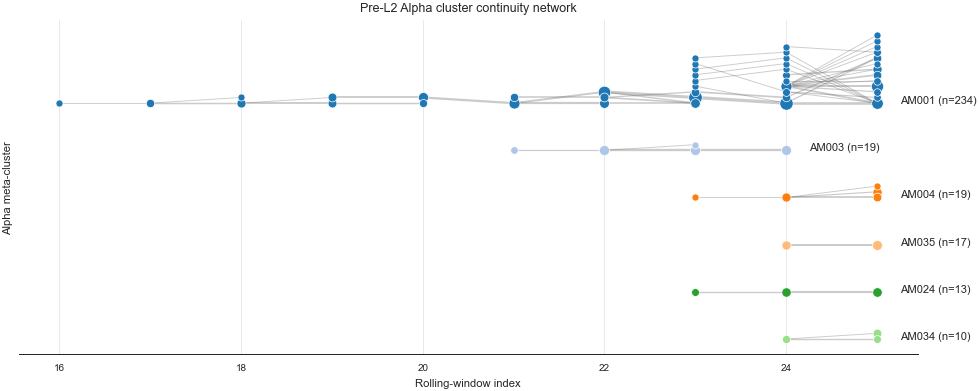

In [46]:
plot_meta = meta_summary.loc[
    meta_summary["n_alpha_sequences"] >= MIN_META_CLUSTER_SEQUENCES,
    "meta_cluster_id",
].head(12).tolist()
plot_nodes = node_table[node_table["meta_cluster_id"].isin(plot_meta)].copy()
H = G.subgraph(plot_nodes["node_id"]).copy()

palette = dict(zip(plot_meta, sns.color_palette("tab20", n_colors=max(len(plot_meta), 1))))
meta_rank = {meta: i for i, meta in enumerate(plot_meta)}
positions = {}
for _, row in plot_nodes.sort_values(["meta_cluster_id", "window_idx", "n_alpha_sequences"]).iterrows():
    same_window_rank = (
        plot_nodes[(plot_nodes["meta_cluster_id"] == row["meta_cluster_id"]) & (plot_nodes["window_idx"] == row["window_idx"])]
        .sort_values("node_id")
        .reset_index(drop=True)
        .query("node_id == @row.node_id")
        .index
    )
    jitter = 0 if len(same_window_rank) == 0 else (same_window_rank[0] - 0.5) * 0.12
    positions[row["node_id"]] = (row["window_idx"], -meta_rank[row["meta_cluster_id"]] + jitter)

fig, ax = plt.subplots(figsize=(10, max(3.5, 0.35 * len(plot_meta) + 2)))
for source, target, data in H.edges(data=True):
    x0, y0 = positions[source]
    x1, y1 = positions[target]
    ax.plot([x0, x1], [y0, y1], color="#6b6b6b", alpha=0.35, lw=0.35 + np.log1p(data.get("weight", 1)) * 0.45, zorder=1)

for _, row in plot_nodes.iterrows():
    x, y = positions[row["node_id"]]
    ax.scatter(
        x,
        y,
        s=18 + 8 * np.sqrt(row["n_alpha_sequences"]),
        color=palette[row["meta_cluster_id"]],
        edgecolor="white",
        linewidth=0.5,
        zorder=2,
    )

for meta in plot_meta:
    meta_nodes = plot_nodes[plot_nodes["meta_cluster_id"] == meta]
    if meta_nodes.empty:
        continue
    label = meta_summary.loc[meta_summary["meta_cluster_id"] == meta, "n_alpha_sequences"].iloc[0]
    ax.text(meta_nodes["window_idx"].max() + 0.25, -meta_rank[meta], f"{meta} (n={label})", va="center", fontsize=8)

ax.set_xlabel("Rolling-window index")
ax.set_ylabel("Alpha meta-cluster")
ax.set_yticks([])
ax.set_title("Pre-L2 Alpha cluster continuity network")
ax.grid(axis="x", color="#d9d9d9", lw=0.5, alpha=0.8)
sns.despine(ax=ax, left=True)
fig.tight_layout()
fig.savefig(OUTPUT_FIGURE_DIR / "alpha_pre_l2_meta_cluster_network.png", dpi=300)
plt.show()

## Mutation enrichment by meta-cluster

For each sufficiently large meta-cluster, test each recurrent amino-acid substitution for enrichment against all other pre-L2 Alpha sequences. The filters below are intentionally conservative enough to avoid universal Alpha-defining mutations dominating the output.

In [47]:
eligible_meta = meta_summary.loc[
    meta_summary["n_alpha_sequences"] >= MIN_META_CLUSTER_SEQUENCES,
    "meta_cluster_id",
].tolist()
pre_l2_meta_sequences = seq_meta_primary[seq_meta_primary["meta_cluster_id"].isin(eligible_meta)].copy()

aa_pre = read_nextclade_aa(set(pre_l2_meta_sequences["sequence_id"]))
mutation_long = explode_aa_substitutions(aa_pre).merge(
    pre_l2_meta_sequences[["sequence_id", "meta_cluster_id"]],
    on="sequence_id",
    how="inner",
)

all_ids = set(pre_l2_meta_sequences["sequence_id"])
n_all = len(all_ids)
mut_to_seq = mutation_long.groupby("mutation")["sequence_id"].agg(lambda s: set(s)).to_dict()
global_counts = {mutation: len(ids) for mutation, ids in mut_to_seq.items()}
eligible_mutations = [
    mutation
    for mutation, count in global_counts.items()
    if count >= MIN_MUTATION_SEQUENCES and count / n_all <= MAX_GLOBAL_MUTATION_PREVALENCE
]
seqs_by_meta = pre_l2_meta_sequences.groupby("meta_cluster_id")["sequence_id"].agg(lambda s: set(s)).to_dict()

records = []
for meta, meta_ids in seqs_by_meta.items():
    outside_ids = all_ids - meta_ids
    for mutation in eligible_mutations:
        mutation_ids = mut_to_seq.get(mutation, set())
        a = len(meta_ids & mutation_ids)
        if a == 0:
            continue
        b = len(meta_ids) - a
        c = len(outside_ids & mutation_ids)
        d = len(outside_ids) - c
        odds_ratio, p_value = fisher_exact([[a, b], [c, d]], alternative="greater")
        records.append(
            {
                "meta_cluster_id": meta,
                "mutation": mutation,
                "meta_mutation_count": a,
                "meta_sequence_count": len(meta_ids),
                "background_mutation_count": c,
                "background_sequence_count": len(outside_ids),
                "meta_prevalence": a / len(meta_ids),
                "background_prevalence": c / len(outside_ids) if outside_ids else np.nan,
                "global_prevalence": global_counts[mutation] / n_all,
                "prevalence_difference": a / len(meta_ids) - (c / len(outside_ids) if outside_ids else np.nan),
                "odds_ratio": odds_ratio,
                "p_value": p_value,
            }
        )

mutation_tests = pd.DataFrame(records)
if not mutation_tests.empty:
    mutation_tests["q_value"] = multipletests(mutation_tests["p_value"], method="fdr_bh")[1]
    mutation_tests = mutation_tests.sort_values(
        ["q_value", "prevalence_difference", "meta_prevalence", "meta_mutation_count"],
        ascending=[True, False, False, False],
    )

signature_candidates = mutation_tests[
    (mutation_tests["meta_prevalence"] >= SIGNATURE_MIN_PREVALENCE)
    & (mutation_tests["background_prevalence"] <= SIGNATURE_MAX_BACKGROUND)
    & (mutation_tests["q_value"] <= SIGNATURE_Q_VALUE)
].copy()
signature_candidates["fallback_selection"] = False

if signature_candidates.empty and not mutation_tests.empty:
    signature_candidates = (
        mutation_tests.sort_values(
            ["meta_cluster_id", "prevalence_difference", "meta_prevalence", "q_value"],
            ascending=[True, False, False, True],
        )
        .groupby("meta_cluster_id")
        .head(SIGNATURES_PER_META_CLUSTER)
        .copy()
    )
    signature_candidates["fallback_selection"] = True

selected_signatures = (
    signature_candidates.sort_values(
        ["meta_cluster_id", "q_value", "prevalence_difference", "meta_prevalence"],
        ascending=[True, True, False, False],
    )
    .groupby("meta_cluster_id")
    .head(SIGNATURES_PER_META_CLUSTER)
    .reset_index(drop=True)
)

mutation_tests.to_csv(OUTPUT_TABLE_DIR / "alpha_pre_l2_meta_cluster_mutation_enrichment.csv", index=False)
selected_signatures.to_csv(OUTPUT_TABLE_DIR / "alpha_pre_l2_meta_cluster_signature_mutations.csv", index=False)
display(selected_signatures.head(30))

,meta_cluster_id,mutation,meta_mutation_count,meta_sequence_count,background_mutation_count,background_sequence_count,meta_prevalence,background_prevalence,global_prevalence,prevalence_difference,odds_ratio,p_value,q_value,fallback_selection
0,AM001,ORF1a:L730F,199,234,13,78,0.850427,0.166667,0.679487,0.683761,28.428571,2.669915e-28,2.536419e-27,False
1,AM003,ORF3a:L15F,19,19,16,293,1.000000,0.054608,0.112179,0.945392,inf,3.528188e-21,1.675889e-20,False
2,AM003,ORF1a:F2780L,18,19,19,293,0.947368,0.064846,0.118590,0.882522,259.578947,4.238806e-18,1.150533e-17,False
3,AM003,ORF1b:K1383R,19,19,38,293,1.000000,0.129693,0.182692,0.870307,inf,5.535562e-16,1.168619e-15,False
4,AM004,ORF1a:F2780L,19,19,18,293,1.000000,0.061433,0.118590,0.938567,inf,1.535799e-20,4.863365e-20,False
5,AM004,ORF1b:K1383R,19,19,38,293,1.000000,0.129693,0.182692,0.870307,inf,5.535562e-16,1.168619e-15,False
6,AM004,ORF3a:L15F,16,19,19,293,0.842105,0.064846,0.112179,0.777259,76.912281,1.251478e-14,2.377808e-14,False
7,AM024,S:V1129I,13,13,1,299,1.000000,0.003344,0.044872,0.996656,inf,4.231087e-22,2.679688e-21,False
8,AM024,ORF1a:G268R,12,13,0,299,0.923077,0.000000,0.038462,0.923077,inf,9.066615e-21,3.445314e-20,False
9,AM034,ORF1b:K1383R,10,10,47,302,1.000000,0.155629,0.182692,0.844371,inf,2.074027e-08,3.283875e-08,False


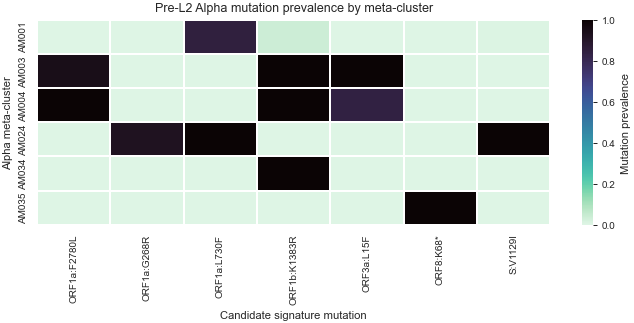

In [52]:
if selected_signatures.empty:
    print("No candidate signature mutations passed the current filters.")
else:
    heatmap_mutations = selected_signatures["mutation"].drop_duplicates().tolist()
    heatmap_meta = selected_signatures["meta_cluster_id"].drop_duplicates().tolist()
    prevalence_records = []
    for meta in heatmap_meta:
        meta_ids = seqs_by_meta[meta]
        for mutation in heatmap_mutations:
            mutation_ids = mut_to_seq.get(mutation, set())
            prevalence_records.append(
                {
                    "meta_cluster_id": meta,
                    "mutation": mutation,
                    "prevalence": len(meta_ids & mutation_ids) / len(meta_ids),
                }
            )
    prevalence_matrix = pd.DataFrame(prevalence_records).pivot(index="meta_cluster_id", columns="mutation", values="prevalence")

    fig_width = max(7, 0.42 * len(heatmap_mutations))
    fig_height = max(3.2, 0.32 * len(heatmap_meta) + 1.5)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    sns.heatmap(
        prevalence_matrix,
        vmin=0,
        vmax=1,
        cmap="mako_r",
        linewidths=0.25,
        linecolor="white",
        cbar_kws={"label": "Mutation prevalence"},
        ax=ax,
    )
    ax.set_xlabel("Candidate signature mutation")
    ax.set_ylabel("Alpha meta-cluster")
    ax.set_title("Pre-L2 Alpha mutation prevalence by meta-cluster")
    fig.tight_layout()
    fig.savefig(OUTPUT_FIGURE_DIR / "alpha_pre_l2_meta_cluster_signature_heatmap.png", dpi=300)
    plt.show()

## Track signature mutation frequencies after L2

The selected mutations are tracked among all primary good-QC sequences and among Alpha sequences only. This is the main descriptive readout for whether pre-L2 Alpha meta-cluster signatures became common later in the Alpha wave.

In [54]:
selected_mutations = selected_signatures["mutation"].drop_duplicates().head(MAX_TRAJECTORY_MUTATIONS).tolist()

if not selected_mutations:
    signature_trajectory = pd.DataFrame()
    print("No selected mutations to track.")
else:
    trajectory_sequences = primary_sequence[
        (primary_sequence["collection_date"] >= network_rows["collection_date"].min() - pd.Timedelta(days=14))
        & (primary_sequence["collection_date"] <= TRAJECTORY_END)
    ].copy()
    trajectory_sequences["collection_week"] = week_start(trajectory_sequences["collection_date"])

    flags = read_nextclade_flags(set(trajectory_sequences["sequence_id"]), selected_mutations)
    col_to_mutation = {mutation_to_col(mutation): mutation for mutation in selected_mutations}
    flag_long = flags.melt(id_vars="sequence_id", var_name="mutation_col", value_name="has_mutation")
    flag_long["mutation"] = flag_long["mutation_col"].map(col_to_mutation)

    trajectory_long = trajectory_sequences[
        ["sequence_id", "collection_date", "collection_week", "is_alpha_pango", "pango_lineage"]
    ].merge(flag_long, on="sequence_id", how="inner")
    trajectory_long["has_mutation"] = trajectory_long["has_mutation"].astype(bool)
    trajectory_long["alpha_with_mutation"] = trajectory_long["is_alpha_pango"] & trajectory_long["has_mutation"]

    signature_trajectory = (
        trajectory_long.groupby(["collection_week", "mutation"], as_index=False)
        .agg(
            total_sequences=("sequence_id", "nunique"),
            total_alpha_sequences=("is_alpha_pango", "sum"),
            n_with_mutation=("has_mutation", "sum"),
            alpha_with_mutation=("alpha_with_mutation", "sum"),
        )
    )
    signature_trajectory["freq_all_sequences"] = signature_trajectory["n_with_mutation"] / signature_trajectory["total_sequences"]
    signature_trajectory["freq_alpha_sequences"] = np.where(
        signature_trajectory["total_alpha_sequences"] > 0,
        signature_trajectory["alpha_with_mutation"] / signature_trajectory["total_alpha_sequences"],
        np.nan,
    )
    signature_trajectory = signature_trajectory.merge(
        selected_signatures[["mutation", "meta_cluster_id"]].drop_duplicates("mutation"),
        on="mutation",
        how="left",
    )

    signature_trajectory.to_csv(OUTPUT_TABLE_DIR / "alpha_pre_l2_signature_mutation_trajectories.csv", index=False)

display(signature_trajectory.head())

,collection_week,mutation,total_sequences,total_alpha_sequences,n_with_mutation,alpha_with_mutation,freq_all_sequences,freq_alpha_sequences,meta_cluster_id
0,2020-08-03,ORF1a:F2780L,192,0,0,0,0.0,NaN,AM003
1,2020-08-03,ORF1a:G268R,192,0,0,0,0.0,NaN,AM024
2,2020-08-03,ORF1a:L730F,192,0,0,0,0.0,NaN,AM001
3,2020-08-03,ORF1b:K1383R,192,0,0,0,0.0,NaN,AM003
4,2020-08-03,ORF3a:L15F,192,0,0,0,0.0,NaN,AM003


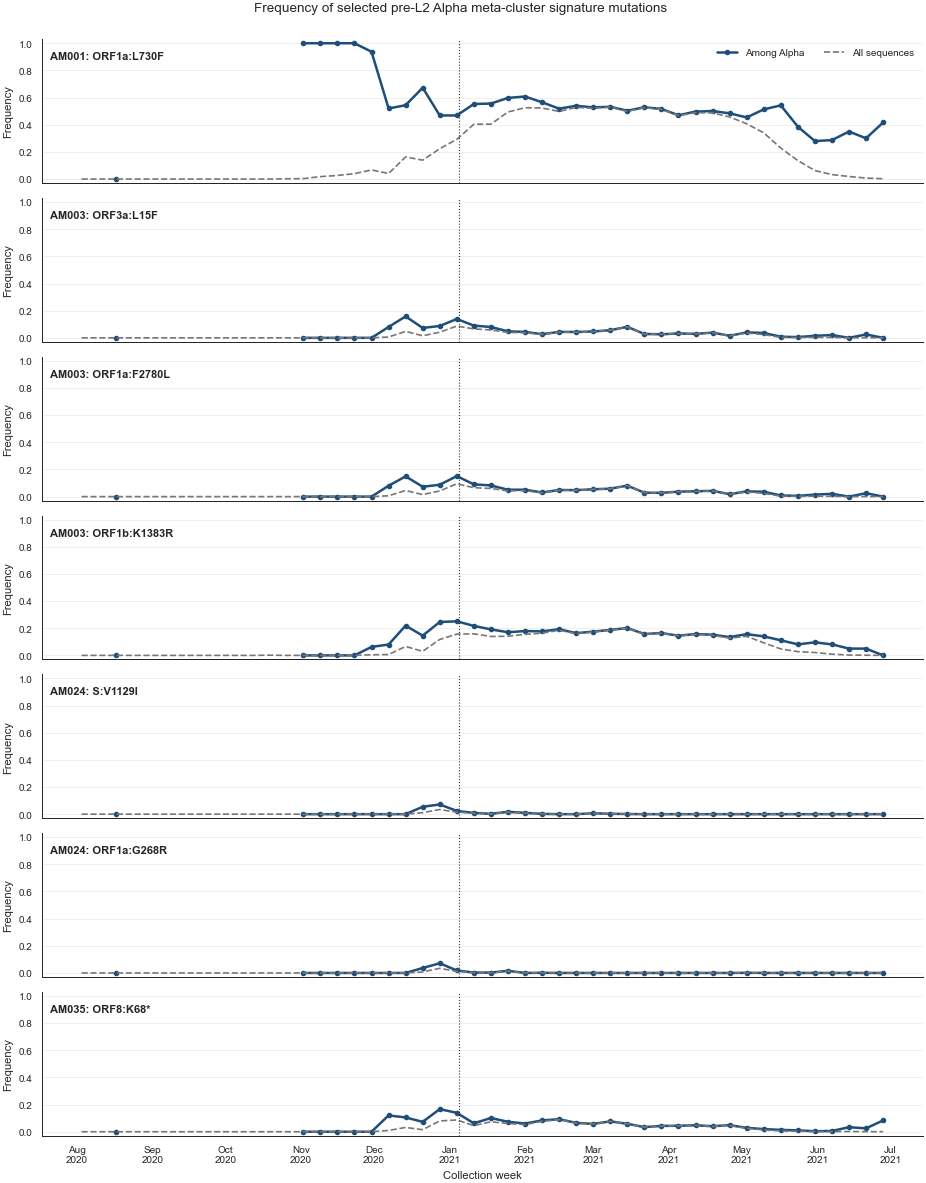

In [55]:
if signature_trajectory.empty:
    print("No signature trajectory to plot.")
else:
    plot_mutations = selected_mutations[:MAX_TRAJECTORY_MUTATIONS]
    n_panels = len(plot_mutations)
    fig, axes = plt.subplots(
        n_panels,
        1,
        figsize=(9.5, max(2.2, 1.7 * n_panels)),
        sharex=True,
        squeeze=False,
    )
    axes = axes.ravel()

    for ax, mutation in zip(axes, plot_mutations):
        dat = signature_trajectory[signature_trajectory["mutation"] == mutation].sort_values("collection_week")
        meta = dat["meta_cluster_id"].dropna().iloc[0] if dat["meta_cluster_id"].notna().any() else "NA"
        ax.plot(dat["collection_week"], dat["freq_alpha_sequences"], color="#1f4e79", lw=1.8, marker="o", ms=3, label="Among Alpha")
        ax.plot(dat["collection_week"], dat["freq_all_sequences"], color="#777777", lw=1.2, ls="--", label="All sequences")
        ax.axvline(L2_START, color="#333333", lw=0.8, ls=":")
        ax.text(0.01, 0.88, f"{meta}: {mutation}", transform=ax.transAxes, ha="left", va="center", fontsize=8, fontweight="bold")
        ax.set_ylim(-0.03, 1.03)
        ax.set_ylabel("Frequency")
        ax.grid(axis="y", color="#dddddd", lw=0.45, alpha=0.75)
        if ax is axes[0]:
            ax.legend(loc="upper right", frameon=False, ncol=2)

    axes[-1].set_xlabel("Collection week")
    axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
    fig.suptitle("Frequency of selected pre-L2 Alpha meta-cluster signature mutations", y=1.0)
    fig.tight_layout()
    fig.savefig(OUTPUT_FIGURE_DIR / "alpha_pre_l2_signature_mutation_trajectories.png", dpi=300)
    plt.show()

## Compact impact table

This table joins each selected signature mutation to its pre-L2 meta-cluster and the later peak frequency among Alpha sequences.

In [56]:
if selected_signatures.empty or signature_trajectory.empty:
    impact_table = pd.DataFrame()
else:
    peak = (
        signature_trajectory.groupby("mutation", as_index=False)
        .agg(
            peak_alpha_frequency=("freq_alpha_sequences", "max"),
            peak_all_sequence_frequency=("freq_all_sequences", "max"),
            first_observed_week=("collection_week", "min"),
        )
    )
    impact_table = (
        selected_signatures.merge(peak, on="mutation", how="left")
        .merge(
            meta_summary[["meta_cluster_id", "n_alpha_sequences", "first_collection_date", "last_collection_date", "health_boards", "local_authorities"]],
            on="meta_cluster_id",
            how="left",
        )
        .sort_values(["peak_alpha_frequency", "meta_prevalence", "prevalence_difference"], ascending=[False, False, False])
    )
    impact_table.to_csv(OUTPUT_TABLE_DIR / "alpha_pre_l2_meta_cluster_signature_impact_summary.csv", index=False)

display(impact_table.head(30))

,meta_cluster_id,mutation,meta_mutation_count,meta_sequence_count,background_mutation_count,background_sequence_count,meta_prevalence,background_prevalence,global_prevalence,prevalence_difference,...,q_value,fallback_selection,peak_alpha_frequency,peak_all_sequence_frequency,first_observed_week,n_alpha_sequences,first_collection_date,last_collection_date,health_boards,local_authorities
0,AM001,ORF1a:L730F,199,234,13,78,0.850427,0.166667,0.679487,0.683761,...,2.536419e-27,False,1.000000,0.529848,2020-08-03,234,2020-11-04,2021-01-04,Greater Glasgow and Clyde (137); Lanarkshire (...,Glasgow City (59); Renfrewshire (22); East Ren...
3,AM003,ORF1b:K1383R,19,19,38,293,1.000000,0.129693,0.182692,0.870307,...,1.168619e-15,False,0.250755,0.199463,2020-08-03,19,2020-12-07,2020-12-18,Grampian (14); Lothian (2); Fife (1); Forth Va...,Aberdeenshire (8); Aberdeen City (6); City of ...
5,AM004,ORF1b:K1383R,19,19,38,293,1.000000,0.129693,0.182692,0.870307,...,1.168619e-15,False,0.250755,0.199463,2020-08-03,19,2020-12-24,2021-01-04,Greater Glasgow and Clyde (6); Tayside (4); Gr...,Glasgow City (6); Dundee City (4); Aberdeen Ci...
9,AM034,ORF1b:K1383R,10,10,47,302,1.000000,0.155629,0.182692,0.844371,...,3.283875e-08,False,0.250755,0.199463,2020-08-03,10,2020-12-27,2021-01-04,Greater Glasgow and Clyde (7); Tayside (2); La...,Glasgow City (3); Inverclyde (2); North Lanark...
10,AM035,ORF8:K68*,17,17,0,295,1.000000,0.000000,0.054487,1.000000,...,2.536419e-27,False,0.166667,0.088843,2020-08-03,17,2020-12-27,2021-01-04,Highland (14); Greater Glasgow and Clyde (1); ...,Highland (14); East Dunbartonshire (1); Moray ...
1,AM003,ORF3a:L15F,19,19,16,293,1.000000,0.054608,0.112179,0.945392,...,1.675889e-20,False,0.157895,0.086792,2020-08-03,19,2020-12-07,2020-12-18,Grampian (14); Lothian (2); Fife (1); Forth Va...,Aberdeenshire (8); Aberdeen City (6); City of ...
6,AM004,ORF3a:L15F,16,19,19,293,0.842105,0.064846,0.112179,0.777259,...,2.377808e-14,False,0.157895,0.086792,2020-08-03,19,2020-12-24,2021-01-04,Greater Glasgow and Clyde (6); Tayside (4); Gr...,Glasgow City (6); Dundee City (4); Aberdeen Ci...
4,AM004,ORF1a:F2780L,19,19,18,293,1.000000,0.061433,0.118590,0.938567,...,4.863365e-20,False,0.151057,0.094340,2020-08-03,19,2020-12-24,2021-01-04,Greater Glasgow and Clyde (6); Tayside (4); Gr...,Glasgow City (6); Dundee City (4); Aberdeen Ci...
2,AM003,ORF1a:F2780L,18,19,19,293,0.947368,0.064846,0.118590,0.882522,...,1.150533e-17,False,0.151057,0.094340,2020-08-03,19,2020-12-07,2020-12-18,Grampian (14); Lothian (2); Fife (1); Forth Va...,Aberdeenshire (8); Aberdeen City (6); City of ...
7,AM024,S:V1129I,13,13,1,299,1.000000,0.003344,0.044872,0.996656,...,2.679688e-21,False,0.071429,0.034091,2020-08-03,13,2020-12-23,2021-01-04,Borders (13),Scottish Borders (13)
